<a href="https://colab.research.google.com/github/Rithvikns/python/blob/main/Framework/Pytorch/Project_3-GNN/GNN_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install networkx matplotlib


In [15]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random




In [21]:
# 1. Generate a Sample Causal Graph (DAG)
def generate_causal_graph():
    G = nx.DiGraph()

    # Adding nodes (representing events)
    nodes = [f"E{i}" for i in range(1, 11)]  # 10 events
    G.add_nodes_from(nodes)

    # Adding directed edges (causal relationships)
    edges = [("E1", "E3"), ("E1", "E4"), ("E2", "E5"), ("E3", "E6"), ("E10", "E18"),("E5", "E1"),("E1", "E10"),("E6", "E2"),("E5", "E9"),("E10", "E3"),("E2", "E8"),
             ("E4", "E6"), ("E5", "E7"), ("E6", "E8"), ("E7", "E9"), ("E8", "E10")]
    G.add_edges_from(edges)

    return G



In [22]:
# 2. Causal BFS Sampling Method
def causal_bfs_sampling(G, start_node, depth=2):
    """
    Extracts a causality-preserving subgraph using BFS from a given node.

    Args:
    - G: Original directed causal graph (DAG).
    - start_node: Failure node to begin BFS expansion.
    - depth: Maximum number of levels to explore.

    Returns:
    - Subgraph as a NetworkX DiGraph.
    """
    visited = set()
    queue = [(start_node, 0)]  # (node, depth_level)
    subgraph_nodes = set()

    while queue:
        node, level = queue.pop(0)
        if node not in visited and level <= depth:
            visited.add(node)
            subgraph_nodes.add(node)
            # Add parent and child nodes to maintain causality
            for parent in G.predecessors(node):
                queue.append((parent, level + 1))
            for child in G.successors(node):
                queue.append((child, level + 1))

    # Create subgraph
    subgraph = G.subgraph(subgraph_nodes).copy()
    return subgraph

In [23]:
# 3. Visualizing the Graph
def visualize_graph(G, title="Graph"):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=2000, font_size=10)
    plt.title(title)
    plt.show()

Selected failure node for sampling: E9


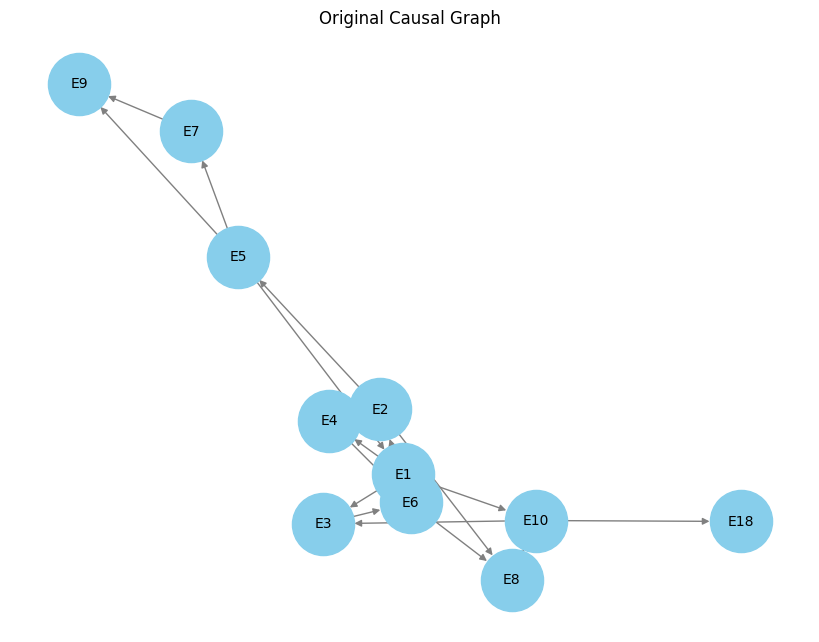

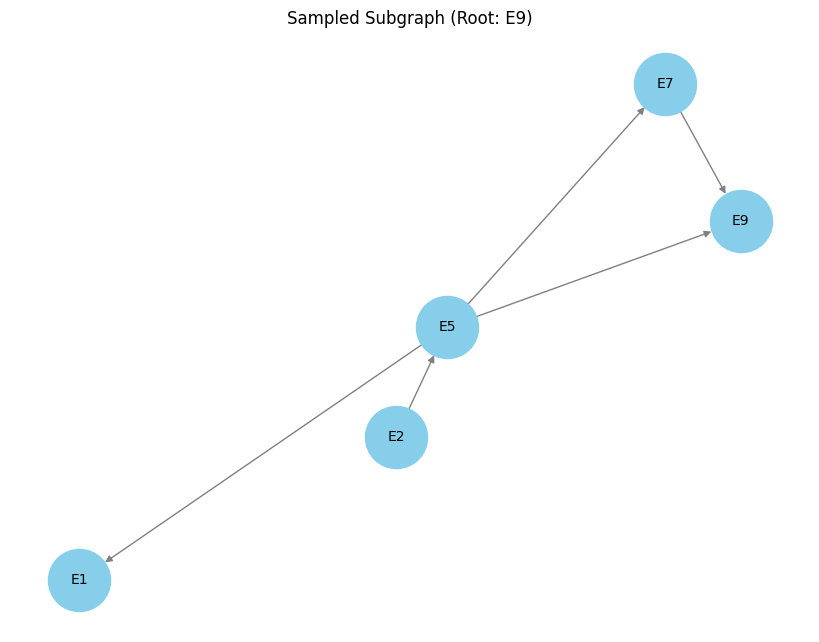

In [24]:
# Main Execution
if __name__ == "__main__":
    causal_graph = generate_causal_graph()

    # Pick a random failure node as root for subgraph sampling
    failure_node = random.choice(list(causal_graph.nodes))
    print(f"Selected failure node for sampling: {failure_node}")

    # Generate subgraph
    sampled_subgraph = causal_bfs_sampling(causal_graph, failure_node, depth=2)

    # Visualize original and sampled subgraphs
    visualize_graph(causal_graph, "Original Causal Graph")
    visualize_graph(sampled_subgraph, f"Sampled Subgraph (Root: {failure_node})")

In [25]:
def fault_tree_analysis(G, top_event):
    """
    Performs Fault Tree Analysis (FTA) on the given subgraph.

    Args:
    - G: Sampled subgraph (DAG).
    - top_event: Root failure event (fault event).

    Returns:
    - Root cause ranking as a dictionary (event: failure probability).
    """
    # 3.1 Compute Minimal Cut Sets (MCS)
    # A Minimal Cut Set is a minimal set of basic events that cause the top event failure.
    minimal_cut_sets = []

    # A cut set is any path from a leaf node (basic failure event) to the top event
    for path in nx.all_simple_paths(G, source=list(G.nodes)[0], target=top_event):
        minimal_cut_sets.append(path)

    print(f"Minimal Cut Sets: {minimal_cut_sets}")

    # 3.2 Assign Failure Probabilities (Random for Demo)
    failure_probs = {node: round(np.random.uniform(0.05, 0.2), 2) for node in G.nodes}

    # 3.3 Compute Root Cause Ranking (Failure Probability Contribution)
    root_cause_ranking = {}
    for cut_set in minimal_cut_sets:
        cut_set_prob = np.prod([failure_probs[node] for node in cut_set])  # Multiply failure probabilities
        for node in cut_set:
            if node not in root_cause_ranking:
                root_cause_ranking[node] = 0
            root_cause_ranking[node] += cut_set_prob  # Aggregate probability contribution

    # Sort by highest contribution to failure
    root_cause_ranking = dict(sorted(root_cause_ranking.items(), key=lambda item: item[1], reverse=True))

    return root_cause_ranking


Selected failure node for sampling: E9
Minimal Cut Sets: [['E7', 'E9']]


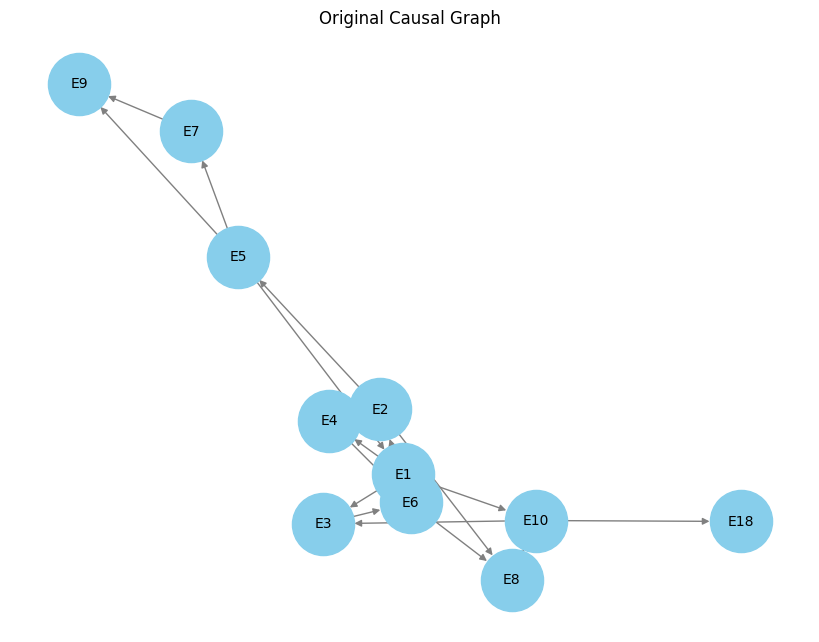

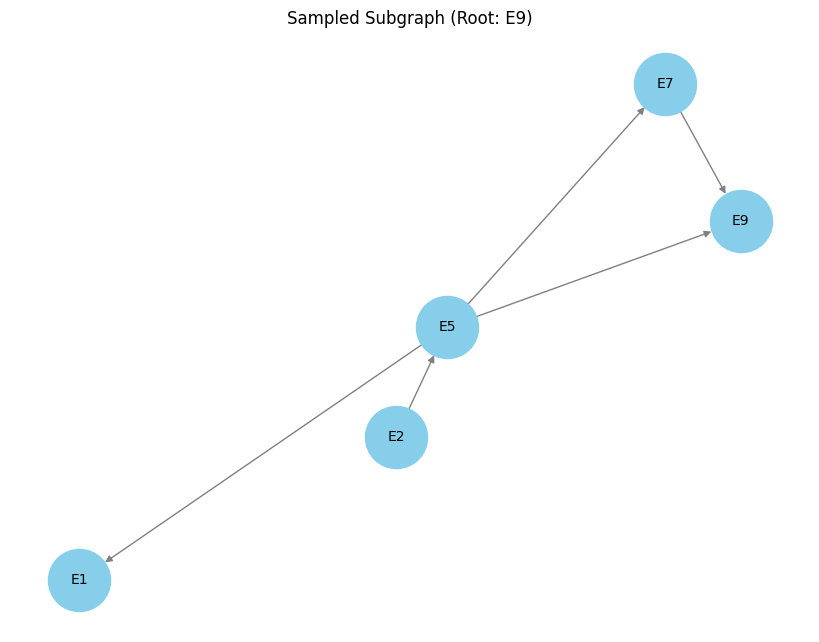


Root Cause Ranking (Failure Contribution):
E7: 0.0117
E9: 0.0117


In [27]:
if __name__ == "__main__":
    causal_graph = generate_causal_graph()

    # Pick a random failure node as root for subgraph sampling
    failure_node = random.choice(list(causal_graph.nodes))
    print(f"Selected failure node for sampling: {failure_node}")

    # Generate subgraph
    sampled_subgraph = causal_bfs_sampling(causal_graph, failure_node, depth=2)

    # Perform Fault Tree Analysis (FTA)
    root_cause_ranking = fault_tree_analysis(sampled_subgraph, failure_node)

    # Visualize original and sampled subgraphs
    visualize_graph(causal_graph, "Original Causal Graph")
    visualize_graph(sampled_subgraph, f"Sampled Subgraph (Root: {failure_node})")

    # Print Root Cause Ranking
    print("\nRoot Cause Ranking (Failure Contribution):")
    for event, prob in root_cause_ranking.items():
        print(f"{event}: {prob:.4f}")